# Phase 2b: OCR on PDFs and benchmarking

In this phase we will explore several open source OCR model on our articles and compare the results to the md files Hugging Face produced with chandra2. 

In [ ]:
import os
from dotenv import load_dotenv

_ = load_dotenv(override=True)

In [1]:
from PIL import Image
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Dict, Any
import duckdb
from pdf2image import convert_from_path

In [2]:
# Create a df with the pdf file paths and the corresponding image file paths
conn = duckdb.connect("./data/arxiv_metadata.duckdb")
df = conn.execute(
    """
    SELECT *
    FROM papers
    WHERE pdf_path IS NOT NULL AND latex_extracted = True
    """
).fetchdf()

conn.close()

In [3]:
df.head()

,arxiv_id,title,abstract,submitted_date,updated_date,primary_category,doi,comments,license,version_count,github_url,has_code,pdf_path,latex_source_path,latex_extracted
0,2401.01623,Can AI Be as Creative as Humans?,Creativity serves as a cornerstone for socie...,2024-01-03,2024-01-26,cs.AI,None,"The paper examines AI's creativity, introducin...",http://arxiv.org/licenses/nonexclusive-distrib...,4,None,False,data/raw/pdfs/2401.01623.pdf,data/raw/sources/2401.01623.tar.gz,True
1,2401.02118,Radio Map-Based Spectrum Sharing for Joint Com...,The sixth-generation (6G) network is expecte...,2024-01-04,2024-06-28,cs.IT,None,None,http://arxiv.org/licenses/nonexclusive-distrib...,2,None,False,data/raw/pdfs/2401.02118.pdf,data/raw/sources/2401.02118.tar.gz,True
2,2401.02687,PAHD: Perception-Action based Human Decision M...,Synthetic Aperture Radar (SAR) images are co...,2024-01-05,2024-01-08,cs.CV,None,None,http://creativecommons.org/licenses/by/4.0/,1,None,False,data/raw/pdfs/2401.02687.pdf,data/raw/sources/2401.02687.tar.gz,True
3,2401.05171,Multivariate Extreme Value Theory Based Rate S...,Diversity schemes play a vital role in impro...,2024-01-10,2024-01-12,cs.IT,None,"11 pages, 6 figures, submitted to the IEEE Tra...",http://arxiv.org/licenses/nonexclusive-distrib...,2,None,False,data/raw/pdfs/2401.05171.pdf,data/raw/sources/2401.05171.tar.gz,True
4,2401.07437,BoNuS: Boundary Mining for Nuclei Segmentation...,Nuclei segmentation is a fundamental prerequ...,2024-01-15,2024-01-17,cs.CV,None,Accepted by IEEE Transactions on Medical Imaging,http://creativecommons.org/licenses/by/4.0/,1,https://github.com/hust-linyi/bonus.,True,data/raw/pdfs/2401.07437.pdf,data/raw/sources/2401.07437.tar.gz,True


In [ ]:
df.shape

(916, 15)

In [5]:
df.to_csv("./data/pdf_data.csv", index=False)

In [2]:
df = pd.read_csv("./data/pdf_data.csv")

In [ ]:
import easyocr
reader = easyocr.Reader(['en']) # this needs to run only once to load the model into memory

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [5]:
result = reader.readtext("./data/sample_page.png")
result

[([[np.int32(585), np.int32(322)],
   [np.int32(1897), np.int32(322)],
   [np.int32(1897), np.int32(401)],
   [np.int32(585), np.int32(401)]],
  'CEV-LM: Controlled Edit Vector Language Model',
  np.float64(0.9280551796389535)),
 ([[np.int32(678), np.int32(393)],
   [np.int32(768), np.int32(393)],
   [np.int32(768), np.int32(447)],
   [np.int32(678), np.int32(447)]],
  'for',
  np.float64(0.9999888502748309)),
 ([[np.int32(765), np.int32(387)],
   [np.int32(1801), np.int32(387)],
   [np.int32(1801), np.int32(468)],
   [np.int32(765), np.int32(468)]],
  'Shaping Natural Language Generations',
  np.float64(0.9998140960357332)),
 ([[np.int32(672), np.int32(541)],
   [np.int32(1081), np.int32(541)],
   [np.int32(1081), np.int32(615)],
   [np.int32(672), np.int32(615)]],
  'Samraj Moorjanil',
  np.float64(0.8336791444772045)),
 ([[np.int32(1097), np.int32(546)],
   [np.int32(1431), np.int32(546)],
   [np.int32(1431), np.int32(601)],
   [np.int32(1097), np.int32(601)]],
  'Adit Krishnanl',
 

In [6]:
page = result[0]
print(page)

([[np.int32(585), np.int32(322)], [np.int32(1897), np.int32(322)], [np.int32(1897), np.int32(401)], [np.int32(585), np.int32(401)]], 'CEV-LM: Controlled Edit Vector Language Model', np.float64(0.9280551796389535))


In [ ]:
page[0]

[[np.int32(585), np.int32(322)],
 [np.int32(1897), np.int32(322)],
 [np.int32(1897), np.int32(401)],
 [np.int32(585), np.int32(401)]]

In [8]:
page[1]

'CEV-LM: Controlled Edit Vector Language Model'

In [12]:
boxes = page[0]
text = page[1]
score = page[2]


In [14]:
boxes

[[np.int32(585), np.int32(322)],
 [np.int32(1897), np.int32(322)],
 [np.int32(1897), np.int32(401)],
 [np.int32(585), np.int32(401)]]

In [16]:
for x, y in boxes:
    print(f"({x}, {y})")
    

(585, 322)
(1897, 322)
(1897, 401)
(585, 401)


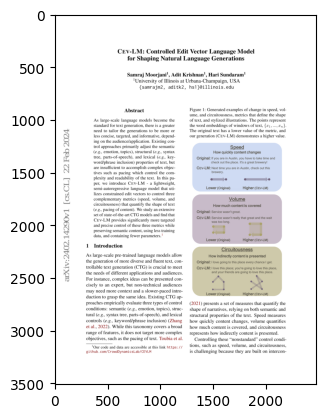

In [19]:
img = cv2.imread("./data/sample_page.png")
plt.imshow(img)

In [ ]:
img = cv2.imread("./data/sample_page.png")

for box in zip(boxes):
    pts = np.array(box, dtype = int)
    cv2.polylines(img, [pts], isClosed=True, color=(0,255,0), thickness=2)
    x, y = pts[0]

C: [np.int32(585), np.int32(322)]
E: [np.int32(1897), np.int32(322)]
V: [np.int32(1897), np.int32(401)]
-: [np.int32(585), np.int32(401)]


In [ ]:
print(f"Extracted {len()}")

dtype('float64')

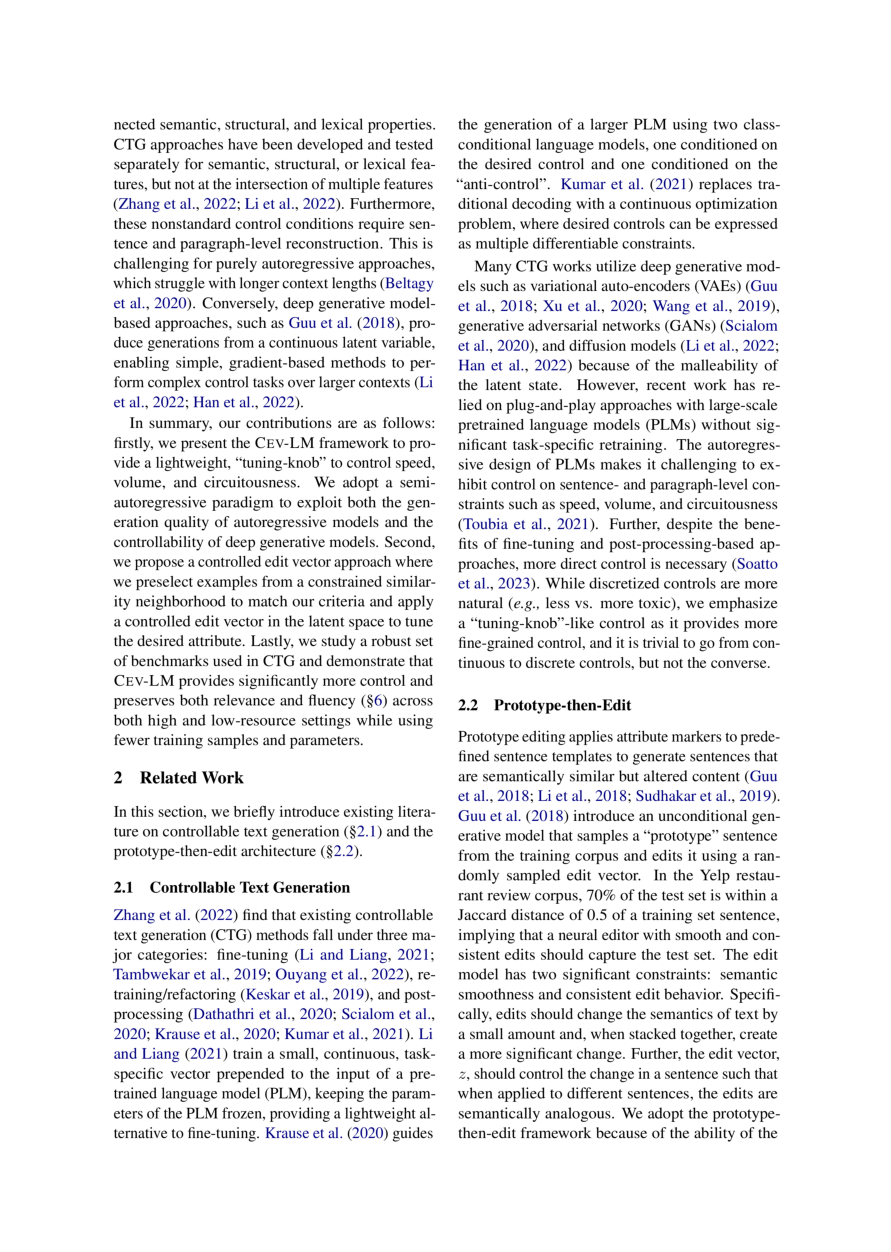

In [3]:
from PIL import Image

# Récupère le chemin du PDF depuis ton DataFrame
pdf_path = df.iloc[50]["pdf_path"]

# Convertit le PDF en images (une liste de PIL.Image)
images = convert_from_path(pdf_path, dpi=300)

# Affiche la première page
plt.figure(figsize=(30, 16))
plt.imshow(images[1])  # images[0] est un objet PIL.Image
plt.axis('off')  # Désactive les axes
plt.show()


In [6]:
images[0].save("./data/sample_page.png")

In [7]:
from paddleocr import PaddleOCR

# Initialize PaddleOCR 
ocr = PaddleOCR(lang='en')

result = ocr.predict("./data/sample_page.png")
page = result[0]

texts = page['rec_texts']      # recognized text strings
scores = page['rec_scores']    # confidence scores
boxes = page['rec_polys']      # bounding box coordinates

print(f"Extracted {len(texts)} text regions")
print("\nFirst 10 regions:")
for text, score, box in list(zip(texts, scores, boxes))[:10]:
    coords = box.astype(int).tolist()
    print(f"{text:40} | {score:.3f} | {coords}")

/usr/local/lib/python3.12/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/dist-packages/torch/library.py:357: UserWarning: Warning only once for all operators,  other operators may also be overridden.
  Overriding a previously registered kernel for the same operator and the same dispatch key
  operator: flash_attn::_flash_attn_backward(Tensor dout, Tensor q, Tensor k, Tensor v, Tensor out, Tensor softmax_lse, Tensor(a6!)? dq, Tensor(a7!)? dk, Tensor(a8!)? dv, float dropout_p, float softmax_scale, bool causal, SymInt window_size_left, SymInt window_size_right, float softcap, Tensor? alibi_s

: 

: 

: 